# Análisis de Datos II — Actividad 2: Calidad, drift y anomalías

**Dataset:** [Data Science Salaries 2023](https://www.kaggle.com/datasets/arnabchaki/data-science-salaries-2023)


## 1. Carga del dataset

In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

RANDOM_STATE = 42

In [2]:
DATA_PATH = "data/ds_salaries.csv"

df = pd.read_csv(DATA_PATH)
print(f"Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}")
df.head()

Filas: 3755  |  Columnas: 11


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


### 1.1 Dataset split by period

In [3]:
REF_YEARS = [2020, 2021]
CUR_YEARS = [2022, 2023]

df_ref = df[df["work_year"].isin(REF_YEARS)].copy()   # periodo de referencia
df_cur = df[df["work_year"].isin(CUR_YEARS)].copy()   # periodo actual

print(f"Referencia (2020-2021): {len(df_ref):5d} filas ({len(df_ref)/len(df):6.1%})")
print(f"Actual     (2022-2023): {len(df_cur):5d} filas ({len(df_cur)/len(df):6.1%})")
print(f"Total sin asignar     : {len(df) - len(df_ref) - len(df_cur):5d} filas")
print()
print("Filas por año:")
print(df["work_year"].value_counts().sort_index().to_string())


Referencia (2020-2021):   306 filas (  8.1%)
Actual     (2022-2023):  3449 filas ( 91.9%)
Total sin asignar     :     0 filas

Filas por año:
work_year
2020      76
2021     230
2022    1664
2023    1785


**OBSERVACIONES**
- El período de referencia (2020-2021) concentra solo 306 filas frente a 3449 del período actual (2022-2023), es decir menos del 10% del dataset.

## 2. Quality check

Se utiliza **Great Expectations** sobre las siguientes tres variables del dataset:

| Variable | Tipo esperado | Dominio / rango válido |
|---|---|---|
| `experience_level` | categórica (`str`) | `EN`, `MI`, `SE`, `EX` |
| `salary_in_usd` | numérica entera (`int64`) | 1.000 – 1.000.000 USD anuales |
| `company_location` | categórica (`str`) | código ISO 3166-1 alpha-2 (dos letras mayúsculas) |

La evaluación comprende:
- **completitud**: qué exista la columna y ausencia de missings.
- **validez**: valores dentro del dominio o rango posible.
- **unicidad**: ausencia de instancias repetidas. No implica necesariamente una error.
- **tipo de dato**: que se corresponda con el tipo de dato esperado.

### 2.1 Setup de Great Expectations

In [4]:
import warnings

import great_expectations as gx
import great_expectations.expectations as gxe

warnings.filterwarnings("ignore", category=UserWarning)

# Contexto efimero: la suite vive solo en memoria, no se persiste en disco.
context = gx.get_context(mode="ephemeral")

batch = (
    context.data_sources.add_pandas("pandas_ds")
    .add_dataframe_asset(name="ds_salaries")
    .add_batch_definition_whole_dataframe("full_table")
    .get_batch(batch_parameters={"dataframe": df})
)

print(f"Great Expectations {gx.__version__}  |  batch de {df.shape[0]} filas x {df.shape[1]} columnas")

Great Expectations 1.23.1  |  batch de 3755 filas x 11 columnas


### 2.2 Definición de las expectativas

In [5]:
QC_VARS = ["experience_level", "salary_in_usd", "company_location"]

EXPERIENCE_LEVELS = ["EN", "MI", "SE", "EX"]   # Entry / Mid / Senior / Executive
SALARY_MIN, SALARY_MAX = 1_000, 1_000_000      # rango plausible de un salario anual en USD
EXPECTED_DTYPES = {
    "experience_level": "str",
    "salary_in_usd": "int64",
    "company_location": "str",
}
# Codigos de pais ISO 3166-1 alpha-2: dominio valido de company_location.
ISO_3166_ALPHA2 = (
    "AD AE AF AG AI AL AM AO AQ AR AS AT AU AW AX AZ BA BB BD BE BF BG BH BI BJ BL BM BN BO BQ BR BS BT BV BW BY BZ CA CC CD CF CG CH CI CK CL CM CN CO CR CU CV CW CX CY CZ DE DJ DK DM DO DZ EC EE EG EH ER ES ET FI FJ FK FM FO FR GA GB GD GE GF GG GH GI GL GM GN GP GQ GR GS GT GU GW GY HK HM HN HR HT HU ID IE IL IM IN IO IQ IR IS IT JE JM JO JP KE KG KH KI KM KN KP KR KW KY KZ LA LB LC LI LK LR LS LT LU LV LY MA MC MD ME MF MG MH MK ML MM MN MO MP MQ MR MS MT MU MV MW MX MY MZ NA NC NE NF NG NI NL NO NP NR NU NZ OM PA PE PF PG PH PK PL PM PN PR PS PT PW PY QA RE RO RS RU RW SA SB SC SD SE SG SH SI SJ SK SL SM SN SO SR SS ST SV SX SY SZ TC TD TF TG TH TJ TK TL TM TN TO TR TT TV TW TZ UA UG UM US UY UZ VA VC VE VG VI VN VU WF WS YE YT ZA ZM ZW"
).split()

suite = context.suites.add(gx.ExpectationSuite(name="calidad_salaries"))


def dim(nombre):
    """Etiqueta la expectativa con la dimension de calidad que evalua."""
    return {"dimension": nombre}


# --- Completitud: la columna existe y no tiene valores nulos -------------------
for col in QC_VARS:
    suite.add_expectation(gxe.ExpectColumnToExist(column=col, meta=dim("Completitud")))
    suite.add_expectation(gxe.ExpectColumnValuesToNotBeNull(column=col, meta=dim("Completitud")))

# --- Tipo de dato -------------------------------------------------------------
for col, tipo in EXPECTED_DTYPES.items():
    suite.add_expectation(
        gxe.ExpectColumnValuesToBeOfType(column=col, type_=tipo, meta=dim("Tipo de dato"))
    )

# --- Validez: los valores caen dentro del dominio / rango posible -------------
suite.add_expectation(
    gxe.ExpectColumnValuesToBeInSet(
        column="experience_level", value_set=EXPERIENCE_LEVELS, meta=dim("Validez")
    )
)
suite.add_expectation(
    gxe.ExpectColumnValuesToBeBetween(
        column="salary_in_usd", min_value=SALARY_MIN, max_value=SALARY_MAX, meta=dim("Validez")
    )
)
suite.add_expectation(
    gxe.ExpectColumnValuesToMatchRegex(
        column="company_location", regex=r"^[A-Z]{2}$", meta=dim("Validez")
    )
)
suite.add_expectation(
    gxe.ExpectColumnValuesToBeInSet(
        column="company_location", value_set=ISO_3166_ALPHA2, meta=dim("Validez")
    )
)

# --- Unicidad -----------------------------------------------------------------
# A nivel de instancia: la fila completa no deberia repetirse.
suite.add_expectation(
    gxe.ExpectCompoundColumnsToBeUnique(column_list=list(df.columns), meta=dim("Unicidad"))
)

print(f"{len(suite.expectations)} expectativas definidas")

14 expectativas definidas


### 2.3 Ejecución de la suite

In [6]:
results = batch.validate(suite)

filas = []
for r in results.results:
    cfg, res = r.expectation_config, r.result

    n = res.get("unexpected_count", 0 if r.success else None)
    pct = res.get("unexpected_percent", 0.0 if r.success else None)
    filas.append(
        {
            "variable": cfg.kwargs.get("column", "fila completa"),
            "dimension": cfg.meta.get("dimension"),
            "expectativa": cfg.type,
            "resultado": "OK" if r.success else "FALLA",
            "n_inesperados": n,
            "%_inesperados": round(pct, 2) if pct is not None else None,
        }
    )

qc = pd.DataFrame(filas)

cumplidas = sum(r.success for r in results.results)
print(f"Resultado global de la suite: {'OK' if results.success else 'FALLA'}")
print(f"Expectativas cumplidas: {cumplidas}/{len(results.results)}")
qc

Calculating Metrics:   0%|          | 0/54 [00:00<?, ?it/s]

Resultado global de la suite: FALLA
Expectativas cumplidas: 13/14


,variable,dimension,expectativa,resultado,n_inesperados,%_inesperados
0,experience_level,Completitud,expect_column_to_exist,OK,0,0.00
1,experience_level,Completitud,expect_column_values_to_not_be_null,OK,0,0.00
2,experience_level,Tipo de dato,expect_column_values_to_be_of_type,OK,0,0.00
3,experience_level,Validez,expect_column_values_to_be_in_set,OK,0,0.00
4,salary_in_usd,Completitud,expect_column_to_exist,OK,0,0.00
5,salary_in_usd,Completitud,expect_column_values_to_not_be_null,OK,0,0.00
6,salary_in_usd,Tipo de dato,expect_column_values_to_be_of_type,OK,0,0.00
7,salary_in_usd,Validez,expect_column_values_to_be_between,OK,0,0.00
8,company_location,Completitud,expect_column_to_exist,OK,0,0.00
9,company_location,Completitud,expect_column_values_to_not_be_null,OK,0,0.00


### 2.4 Detalle de los duplicados

In [7]:
dup_todas = df.duplicated(keep=False)      # toda fila que participa de un grupo duplicado
dup_extra = df.duplicated(keep="first")    # copias de otra

print(f"Filas involucradas en duplicados exactos : {dup_todas.sum():5d} ({dup_todas.mean():6.1%})")
print(f"Copias                                   : {dup_extra.sum():5d} ({dup_extra.mean():6.1%})")
print(f"Filas distintas                          : {len(df) - dup_extra.sum():5d}")
print(f"Instancias duplicadas                    : {dup_todas.sum() - dup_extra.sum():5d}")

print("\nCopias por periodo:")
for nombre, parte in [("Referencia (2020-2021)", df_ref), ("Actual (2022-2023)", df_cur)]:
    d = parte.duplicated(keep="first")
    print(f"  {nombre:22s}: {d.sum():5d} de {len(parte):5d} filas ({d.mean():6.1%})")

print("\nInstancias duplicadas mas frecuentes:")
(
    df[dup_todas]
    .groupby(list(df.columns), dropna=False)
    .size()
    .sort_values(ascending=False)
    .head(5)
    .reset_index(name="n_repeticiones")
)

Filas involucradas en duplicados exactos :  1715 ( 45.7%)
Copias                                   :  1171 ( 31.2%)
Filas distintas                          :  2584
Instancias duplicadas                    :   544

Copias por periodo:
  Referencia (2020-2021):     3 de   306 filas (  1.0%)
  Actual (2022-2023)    :  1168 de  3449 filas ( 33.9%)

Instancias duplicadas mas frecuentes:


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,n_repeticiones
0,2022,SE,FT,Data Scientist,191475,USD,191475,US,100,US,M,21
1,2022,SE,FT,Data Scientist,141525,USD,141525,US,100,US,M,21
2,2023,SE,FT,Data Engineer,252000,USD,252000,US,0,US,M,13
3,2023,SE,FT,Data Engineer,129000,USD,129000,US,0,US,M,13
4,2022,SE,FT,Data Scientist,185900,USD,185900,US,0,US,M,12


**OBSERVACIONES**

- **Completitud: OK.** Las tres variables existen y no tienen ningún valor nulo (0 missings sobre 3.755 filas), por lo que no hace falta imputar ni descartar registros por este motivo.

- **Tipo de dato: OK.** `experience_level` y `company_location` son cadenas de carácteres y `salary_in_usd` es entero (`int64`), tal como se esperaba.

- **Validez: OK.** `experience_level` solo toma los cuatro códigos del diccionario (`EN`, `MI`, `SE`, `EX`); los 72 valores distintos de `company_location` son códigos ISO 3166-1 alpha-2 válidos de dos letras mayúsculas; `salary_in_usd` cae íntegramente en el rango plausible definido (mínimo 5.132 y máximo 450.000 USD, sin ceros ni negativos).

- **Unicidad a nivel de instancia: Falla.** El dataset no tiene columna de ID, así que la unicidad se evalúa con `expect_compound_columns_to_be_unique` sobre las 11 columnas. Hay 1715 filas involucradas en duplicados exactos (45,7%), que son copias de alguna de las 544 instancias que aparecen repetidas, lo que deja 1171 instancias que son copias y solo 2584 filas realmente distintas. Al no haber identificador no se puede distinguir un duplicado técnico de dos casos genuinamente idénticos, aunque un 45% de filas repetidas en el segundo período es demasiado alto para ser casual.

## 3. Evaluación de drift

Se compara el período de **referencia** (2020-2021, 306 filas) contra el **actual** (2022-2023, 3.449 filas) mediante el *Population Stability Index* (PSI) calculado con **Evidently** (`ValueDrift(method="psi")`), sobre las mismas tres variables de la sección 2.

Umbrales de referencia habituales: 
- **PSI <= 0,1**: sin drift.
- **0,1 < PSI <= 0,25**: drift moderado.
- **0,25 < PSI** drift severo.

### 3.1 Cálculo del PSI

In [8]:
from evidently import DataDefinition, Dataset, Report
from evidently.metrics import ValueDrift

data_definition = DataDefinition(
    numerical_columns=["salary_in_usd"],
    categorical_columns=["experience_level", "company_location"],
)


def psi_por_variable(referencia, actual):
    """PSI de cada variable de QC_VARS entre las dos particiones del dataset."""
    report = Report([ValueDrift(column=col, method="psi") for col in QC_VARS])
    snapshot = report.run(
        Dataset.from_pandas(actual[QC_VARS], data_definition=data_definition),
        Dataset.from_pandas(referencia[QC_VARS], data_definition=data_definition),
    )
    return {m["config"]["column"]: m["value"] for m in snapshot.dict()["metrics"]}


def interpretar(psi):
    if psi < 0.1:
        return "sin drift"
    if psi < 0.25:
        return "drift moderado"
    return "drift severo"

### 3.2 Resultados

In [9]:
psi_full = psi_por_variable(df_ref, df_cur)

# Los duplicados exactos detectados en la seccion 2 se concentran en el periodo actual,
# asi que se recalcula el PSI sin ellos para ver cuanto del drift aportan.
df_dedup = df.drop_duplicates()
psi_dedup = psi_por_variable(
    df_dedup[df_dedup["work_year"].isin(REF_YEARS)],
    df_dedup[df_dedup["work_year"].isin(CUR_YEARS)],
)

drift = pd.DataFrame(
    [
        {
            "variable": col,
            "psi": round(psi_full[col], 3),
            "interpretacion": interpretar(psi_full[col]),
            "psi_sin_duplicados": round(psi_dedup[col], 3),
        }
        for col in QC_VARS
    ]
)
drift

,variable,psi,interpretacion,psi_sin_duplicados
0,experience_level,0.742,drift severo,0.533
1,salary_in_usd,0.920,drift severo,0.758
2,company_location,1.276,drift severo,1.051


### 3.3 Comparativa gráfica de las distribuciones

Cada panel normaliza por el total de **su propio** período, porque el actual tiene más de diez veces las filas de la referencia y en conteos absolutos toda comparación quedaría aplastada. `salary_in_usd` usa los mismos bins que emplea el PSI (regla de Sturges sobre las dos muestras combinadas) y de `company_location` se grafican los 8 países más frecuentes más el resto agrupado, ya que 72 categorías no entran en un eje legible. Los tres paneles se calculan sobre el dataset completo, es decir **con** los duplicados de la sección 2, igual que la columna `psi` de la tabla anterior.

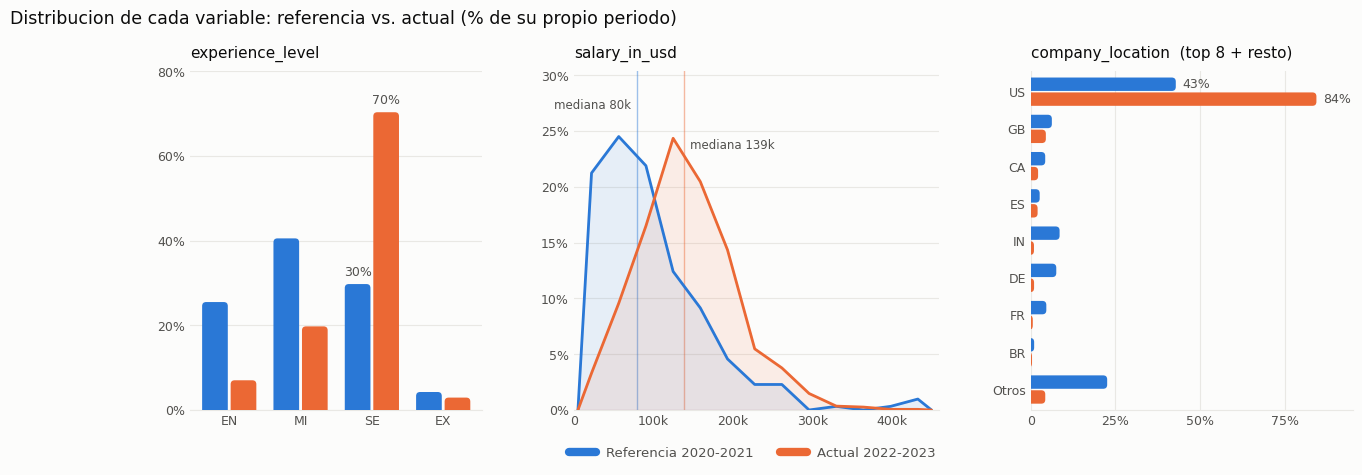

In [10]:
import matplotlib.pyplot as plt
from matplotlib.patches import PathPatch
from matplotlib.path import Path

# Paleta y tokens de texto/superficie (slots categoricos 1 y 2).
SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e9e8e4"
C_REF, C_CUR = "#2a78d6", "#eb6834"
L_REF, L_CUR = "Referencia 2020-2021", "Actual 2022-2023"


def barra(ax, pos, largo, ancho, color, horizontal=False):
    """Barra con la punta de dato redondeada (4px) y base cuadrada."""
    bb = ax.get_window_extent()
    px_v, px_p = (bb.width, bb.height) if horizontal else (bb.height, bb.width)
    lim_v = ax.get_xlim() if horizontal else ax.get_ylim()
    lim_p = ax.get_ylim() if horizontal else ax.get_xlim()
    # 4px traducidos a cada eje por separado: valor y posicion no comparten escala.
    rv = min(4 / px_v * abs(lim_v[1] - lim_v[0]), abs(largo))
    rp = min(4 / px_p * abs(lim_p[1] - lim_p[0]), ancho / 2)
    a, b = pos - ancho / 2, pos + ancho / 2
    v = [(0, a), (largo - rv, a), (largo, a), (largo, a + rp),
         (largo, b - rp), (largo, b), (largo - rv, b), (0, b), (0, a)]
    c = [Path.MOVETO, Path.LINETO, Path.CURVE3, Path.CURVE3,
         Path.LINETO, Path.CURVE3, Path.CURVE3, Path.LINETO, Path.CLOSEPOLY]
    if not horizontal:
        v = [(y, x) for x, y in v]
    ax.add_patch(PathPatch(Path(v, c), facecolor=color, edgecolor="none", linewidth=0, zorder=3))


def estilo(ax, eje_valor="y"):
    """Grilla y ejes finos, solidos y recesivos."""
    ax.set_facecolor(SURFACE)
    for lado in ("top", "right", "left"):
        ax.spines[lado].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.grid(axis=eje_valor, color=GRID, linewidth=0.8, linestyle="-")
    ax.set_axisbelow(True)
    ax.tick_params(colors=INK_2, length=0, labelsize=9)


fig, (ax1, ax2, ax3) = plt.subplots(
    1, 3, figsize=(15, 4.4), facecolor=SURFACE,
    gridspec_kw={"width_ratios": [1, 1.25, 1.1], "wspace": 0.28},
)

# --- experience_level: columnas agrupadas --------------------------------------
orden = ["EN", "MI", "SE", "EX"]
p_ref = df_ref.experience_level.value_counts(normalize=True).reindex(orden).fillna(0) * 100
p_cur = df_cur.experience_level.value_counts(normalize=True).reindex(orden).fillna(0) * 100
estilo(ax1, "y")
ax1.set_xlim(-0.55, len(orden) - 0.45)
ax1.set_ylim(0, 80)
for i, cat in enumerate(orden):
    barra(ax1, i - 0.20, p_ref[cat], 0.36, C_REF)
    barra(ax1, i + 0.20, p_cur[cat], 0.36, C_CUR)
ax1.set_xticks(range(len(orden)))
ax1.set_xticklabels(orden)
ax1.set_yticks([0, 20, 40, 60, 80])
ax1.set_yticklabels([f"{v}%" for v in [0, 20, 40, 60, 80]])
ax1.set_title("experience_level", color=INK, fontsize=11, loc="left", pad=10)
i_se = orden.index("SE")  # etiqueta directa solo sobre el caso extremo: SE se invierte
ax1.text(i_se - 0.20, p_ref["SE"] + 2, f"{p_ref['SE']:.0f}%", ha="center", color=INK_2, fontsize=9)
ax1.text(i_se + 0.20, p_cur["SE"] + 2, f"{p_cur['SE']:.0f}%", ha="center", color=INK_2, fontsize=9)

# --- salary_in_usd: distribuciones superpuestas (mismos bins que usa el PSI) ----
bins = np.histogram_bin_edges(df.salary_in_usd, bins="sturges")
estilo(ax2, "y")
for datos, color in [(df_ref, C_REF), (df_cur, C_CUR)]:
    h = np.histogram(datos.salary_in_usd, bins)[0] / len(datos) * 100
    centros = np.r_[bins[0], (bins[:-1] + bins[1:]) / 2, bins[-1]]
    alturas = np.r_[0, h, 0]
    ax2.fill_between(centros, alturas, color=color, alpha=0.10, zorder=2)
    ax2.plot(centros, alturas, color=color, linewidth=2, solid_capstyle="round",
             solid_joinstyle="round", zorder=3)
ax2.set_xlim(0, 460_000)
ax2.set_xticks([0, 100_000, 200_000, 300_000, 400_000])
ax2.set_xticklabels(["0", "100k", "200k", "300k", "400k"])
ax2.set_ylim(0, ax2.get_ylim()[1] * 1.18)
ax2.set_yticks([t for t in ax2.get_yticks() if 0 <= t <= ax2.get_ylim()[1]])
ax2.set_yticklabels([f"{int(t)}%" for t in ax2.get_yticks()])
ax2.set_title("salary_in_usd", color=INK, fontsize=11, loc="left", pad=10)
tope = ax2.get_ylim()[1]
for datos, color, alto, lado in [(df_ref, C_REF, 0.92, "right"), (df_cur, C_CUR, 0.80, "left")]:
    med = datos.salary_in_usd.median()
    ax2.axvline(med, color=color, linewidth=1, alpha=0.45, zorder=1)
    ax2.text(med + (-8000 if lado == "right" else 8000), tope * alto,
             f"mediana {med/1000:.0f}k", ha=lado, va="top", color=INK_2, fontsize=8.5)

# --- company_location: top 8 + resto (72 categorias no entran en un eje) -------
top = df.company_location.value_counts().head(8).index.tolist()
s_ref = df_ref.company_location.value_counts(normalize=True) * 100
s_cur = df_cur.company_location.value_counts(normalize=True) * 100
cats = top + ["Otros"]
v_ref = [s_ref.get(c, 0) for c in top] + [100 - sum(s_ref.get(c, 0) for c in top)]
v_cur = [s_cur.get(c, 0) for c in top] + [100 - sum(s_cur.get(c, 0) for c in top)]
estilo(ax3, "x")
ax3.set_ylim(len(cats) - 0.45, -0.55)
ax3.set_xlim(0, 95)
for i in range(len(cats)):
    barra(ax3, i - 0.20, v_ref[i], 0.36, C_REF, horizontal=True)
    barra(ax3, i + 0.20, v_cur[i], 0.36, C_CUR, horizontal=True)
ax3.set_yticks(range(len(cats)))
ax3.set_yticklabels(cats)
ax3.set_xticks([0, 25, 50, 75])
ax3.set_xticklabels(["0", "25%", "50%", "75%"])
ax3.set_title("company_location  (top 8 + resto)", color=INK, fontsize=11, loc="left", pad=10)
ax3.text(v_ref[0] + 2, -0.20, f"{v_ref[0]:.0f}%", va="center", color=INK_2, fontsize=9)
ax3.text(v_cur[0] + 2, 0.20, f"{v_cur[0]:.0f}%", va="center", color=INK_2, fontsize=9)

handles = [plt.Line2D([], [], color=c, linewidth=6, solid_capstyle="round") for c in (C_REF, C_CUR)]
fig.legend(handles, [L_REF, L_CUR], loc="lower center", ncol=2, frameon=False,
           bbox_to_anchor=(0.5, -0.03), labelcolor=INK_2, fontsize=9.5)
fig.suptitle("Distribucion de cada variable: referencia vs. actual (% de su propio periodo)",
             color=INK, fontsize=12.5, x=0.005, ha="left", y=1.02)
plt.show()

**OBSERVACIONES**

- **Las tres variables presentan drift severo.** Los tres PSI superan holgadamente el umbral de 0,25. Se trata de distribuciones sustancialmente distintas entre 2020-2021 y 2022-2023.
- **`experience_level`:** el mix de seniority se invierte. `SE` pasa de 29,7% a 70,3% en el período actual, mientras `MI` cae de 40,5% a 19,7% y `EN` de 25,5% a 7,0%. El dataset actual está dominado por perfiles senior.

- **`salary_in_usd`:** la mediana sube de 79.833 a 138.750 USD (+74%) y la media de 93.644 a 141.468 USD. Parte del salto es composición: más seniors como se vio en el punto anterior y no solo una suba salarial real, por lo que las dos variables no driftean de forma independiente.

- **`company_location`:** es la de mayor PSI. EE.UU. pasa de 42,8% a 84,3% de las filas y ese solo bin aporta 0,28 al índice, más que todo el umbral de drift severo. El resto lo explican categorías que se desploman: India 8,5% → 0,9% (aporte 0,17), Alemania 7,5% → 1,0% (0,14), Japón 2,0% → 0,01% (0,10). Los 24 países que aparecen solo en el período actual, en cambio, aportan apenas 0,02 en conjunto.

- **Los duplicados exageran el drift pero no lo explican.** Al recalcular sobre `df.drop_duplicates()` los tres PSI bajan de forma apreciable (0,742 → 0,533; 0,920 → 0,758; 1,276 → 1,051), consistente con que el 33,9% de copias excedentes esté en el período actual. Aun así los tres siguen muy por encima de 0,25, de modo que el drift es real y no un artefacto de los registros repetidos.

**INTERPRETACIÓN**

El drift indica un cambio genuino en la población relevada: el relevamiento de 2022-2023 capta muchas más respuestas y más concentradas en seniors de EE.UU.

Respecto de las implicancias, el PSI mide el corrimiento de las distribuciones marginales: *covariate drift* en las features y, en `salary_in_usd`, *prior drift*. Ninguno de los dos dice nada sobre P(target | features). Si la relación seniority/país → salario se mantiene, no hay *concept drift*, por lo que un modelo bien especificado puede seguir siendo válido aunque la población de entrada haya cambiado por completo. De hecho, buena parte del salto en la mediana salarial se explica por composición, más seniors y más EE.UU., y no por un cambio en cuánto paga cada combinación de seniority y país.

Se recomienda evaluar la performance de las métricas del modelo en períodos por fuera del de entrenamiento para detectar o no *concept drift*. En afirmativo, se recomienda re-entrenar el modelo desde cero. En caso contrario, en vistas de que el dataset "base" representa un 10% de los datos del período actual, se recomienda una actualización del modelo mediante un "fine-tuning" del ya entrenado.


## 4. Detección de anomalías

Se aplican **Isolation Forest** y **Local Outlier Factor** sobre las mismas tres variables. Dos decisiones de preparación:

- **Codificación.** `experience_level` es ordinal (EN < MI < SE < EX), así que se mapea a 0-3; `company_location` se codifica por frecuencia, porque con 72 categorías un one-hot agregaría 72 dimensiones casi vacías. Después se estandariza, ya que LOF trabaja con distancias.
- **Duplicados en el espacio de features.** No alcanza con `drop_duplicates()` sobre las 11 columnas: dos filas distintas en `job_title` o `remote_ratio` pueden caer en el mismo punto de este espacio de 3 variables. Con vecinos a distancia cero la densidad local de LOF diverge y sus scores se van a ~10⁸. Por eso se deduplica **sobre las tres variables usadas**, dejando las combinaciones distintas.

### 4.1 Espacio de features y ajuste de los modelos

In [11]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

CONTAMINACION = 0.02

# Una fila por combinacion distinta de las tres variables (ver nota sobre LOF).
X = df[QC_VARS].drop_duplicates().reset_index(drop=True)

NIVEL = {"EN": 0, "MI": 1, "SE": 2, "EX": 3}
frec_pais = df.company_location.value_counts(normalize=True)
Z = StandardScaler().fit_transform(
    pd.DataFrame({
        "nivel": X.experience_level.map(NIVEL),
        "salario": X.salary_in_usd,
        "frec_pais": X.company_location.map(frec_pais),
    })
)

iso = IsolationForest(n_estimators=200, contamination=CONTAMINACION, random_state=RANDOM_STATE)
lof = LocalOutlierFactor(n_neighbors=20, contamination=CONTAMINACION)

X["flag_iso"] = iso.fit_predict(Z) == -1
X["flag_lof"] = lof.fit_predict(Z) == -1
X["score_iso"] = -iso.score_samples(Z)          # mayor = mas anomalo
X["score_lof"] = -lof.negative_outlier_factor_  # ~1 = normal, mayor = mas anomalo
X["pct_iso"] = X.score_iso.rank(pct=True)
X["pct_lof"] = X.score_lof.rank(pct=True)

print(f"Combinaciones distintas analizadas: {len(X)} (de {len(df)} filas)")
print(f"Marcadas por Isolation Forest: {X.flag_iso.sum()}")
print(f"Marcadas por LOF            : {X.flag_lof.sum()}")
print(f"Marcadas por ambos          : {(X.flag_iso & X.flag_lof).sum()}")
print(f"Correlacion de Spearman entre ambos scores: {X.score_iso.corr(X.score_lof, method='spearman'):.2f}")

Combinaciones distintas analizadas: 1421 (de 3755 filas)
Marcadas por Isolation Forest: 29
Marcadas por LOF            : 29
Marcadas por ambos          : 12
Correlacion de Spearman entre ambos scores: 0.42


### 4.2 Instancia outlier seleccionada

In [12]:
ambos = X[X.flag_iso & X.flag_lof].sort_values("score_lof", ascending=False)
print(f"Instancias marcadas por los dos metodos ({len(ambos)}):")
display(ambos[QC_VARS + ["score_iso", "pct_iso", "score_lof", "pct_lof"]].round(3))

# Se elige la de mayor score LOF dentro de la interseccion.
caso = ambos.iloc[0]
print(f"\nInstancia elegida -> {caso.experience_level} | "
      f"{caso.salary_in_usd:,} USD | {caso.company_location}")
print(f"  Isolation Forest: score {caso.score_iso:.3f}  (percentil {caso.pct_iso:.1%})")
print(f"  LOF             : score {caso.score_lof:.3f}  (percentil {caso.pct_lof:.1%})")
print("\nFila original completa:")
display(df[(df.experience_level == caso.experience_level)
           & (df.salary_in_usd == caso.salary_in_usd)
           & (df.company_location == caso.company_location)])

Instancias marcadas por los dos metodos (12):


,experience_level,salary_in_usd,company_location,score_iso,pct_iso,score_lof,pct_lof
152,EX,15000,CA,0.662,0.986,4.515,0.996
1200,EX,192037,CA,0.657,0.982,2.804,0.990
454,EN,214618,DE,0.662,0.987,2.692,0.989
75,EN,300000,IN,0.692,0.996,2.647,0.988
1261,MI,450000,US,0.726,0.999,2.617,0.987
1273,EX,153667,PL,0.659,0.984,2.512,0.987
318,SE,423834,IL,0.713,0.997,2.476,0.986
512,EX,160288,GB,0.668,0.989,2.439,0.985
773,MI,430967,GB,0.730,0.999,2.429,0.985
781,EN,200000,CA,0.660,0.985,2.417,0.984



Instancia elegida -> EX | 15,000 USD | CA
  Isolation Forest: score 0.662  (percentil 98.6%)
  LOF             : score 4.515  (percentil 99.6%)

Fila original completa:


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
183,2020,EX,FT,Staff Data Analyst,15000,USD,15000,NG,0,CA,M


### 4.3 ¿Anomalía univariada o multivariada?

In [13]:
s = X.salary_in_usd
q1, q3 = s.quantile([0.25, 0.75])
iqr = q3 - q1
v = caso.salary_in_usd

print("--- Mirando cada variable POR SEPARADO ---")
print(f"salary_in_usd = {v:,}")
print(f"  vallas de Tukey: [{q1 - 1.5*iqr:,.0f} , {q3 + 1.5*iqr:,.0f}]  ->  "
      f"{'FUERA' if not (q1-1.5*iqr <= v <= q3+1.5*iqr) else 'DENTRO del rango normal'}")
print(f"  z-score = {(v - s.mean()) / s.std():.2f}   percentil = {(s < v).mean():.1%}")
for col in ["experience_level", "company_location"]:
    share = (X[col] == caso[col]).mean()
    print(f"{col} = {caso[col]}: {share:.1%} de las combinaciones -> categoria minoritaria, no rara")

print("\n--- Mirando la COMBINACION nivel x salario ---")
grupo = X[X.experience_level == caso.experience_level].salary_in_usd
print(f"salarios dentro de {caso.experience_level}: n={len(grupo)}  "
      f"min={grupo.min():,}  p25={grupo.quantile(0.25):,.0f}  mediana={grupo.median():,.0f}  "
      f"max={grupo.max():,}")
print(f"  z-score condicional (dentro de {caso.experience_level}) = "
      f"{(v - grupo.mean()) / grupo.std():.2f}")
print(f"  es el minimo de su nivel: {v == grupo.min()}; "
      f"el siguiente mas bajo es {sorted(grupo)[1]:,} ({sorted(grupo)[1] / v:.1f}x)")
print(f"  combinaciones {caso.experience_level} con salario < 50.000: "
      f"{((X.experience_level == caso.experience_level) & (X.salary_in_usd < 50_000)).sum()}")

--- Mirando cada variable POR SEPARADO ---
salary_in_usd = 15,000
  vallas de Tukey: [-95,030 , 333,018]  ->  DENTRO del rango normal
  z-score = -1.45   percentil = 3.1%
experience_level = EX: 5.4% de las combinaciones -> categoria minoritaria, no rara
company_location = CA: 5.4% de las combinaciones -> categoria minoritaria, no rara

--- Mirando la COMBINACION nivel x salario ---
salarios dentro de EX: n=77  min=15,000  p25=135,000  mediana=185,000  max=416,000
  z-score condicional (dentro de EX) = -2.32
  es el minimo de su nivel: True; el siguiente mas bajo es 69,741 (4.6x)
  combinaciones EX con salario < 50.000: 1


**OBSERVACIONES**

- **Instancia elegida: `EX` / 15.000 USD / `CA`** — un *Staff Data Analyst* de nivel ejecutivo, contratado full-time por una empresa canadiense en 2020, con residencia en Nigeria. Es una única fila del dataset original.

- **Es una anomalía multivariada, no univariada.** Ninguna de las tres variables la delata por separado: 15.000 USD tiene z = −1,45 y cae holgadamente dentro de las vallas de Tukey (la valla inferior es negativa, así que por ese criterio **ningún** salario puede ser outlier por abajo); `EX` y `CA` son cada uno el 5,4% de las combinaciones, minoritarios pero no raros. Lo anómalo aparece recién al cruzar nivel con salario: dentro de `EX` la mediana es 185.000 USD y el primer cuartil 135.000, con lo que su z-score **condicional** es −2,32; es el mínimo de su nivel y el siguiente ejecutivo peor pago cobra 69.741 USD, 4,6 veces más. Es la única combinación `EX` con salario menor a 50.000. En otras palabras: el punto no está en el borde de ninguna distribución marginal, sino en una región vacía del espacio conjunto.

- **Por qué la detectan los dos métodos.** Aunque miden cosas distintas, coinciden acá porque la instancia es anómala en los dos sentidos:
  - *Isolation Forest* (percentil 98,6) particiona el espacio con cortes aleatorios paralelos a los ejes y puntua por qué tan pocos cortes hacen falta para aislar un punto. Como en la esquina "nivel alto + salario muy bajo" no hay ningún otro punto, un corte en `salario < 50k` seguido de uno en `nivel = EX` ya la deja sola: camino corto, score alto.
  - *LOF* (percentil 99,6) compara la densidad local del punto contra la de sus 20 vecinos. Sus vecinos más cercanos son perfiles `MI`/`SE` de salario bajo, que viven en una zona densa y poblada; la instancia está lejos de ellos en el eje de nivel. Ese cociente de densidades da 4,5, contra ≈1 de un punto normal.

- **La coincidencia es la excepción, no la regla.** La correlación de Spearman entre ambos scores es de solo 0,42 y al 2% de contaminación comparten 12 de las 29 instancias que marca cada uno. Isolation Forest tiende a marcar valores globalmente extremos — los salarios de 400.000+ USD — mientras que LOF marca puntos en bolsones de baja densidad aunque sus valores sean moderados, como los ejecutivos mal pagos. Que una instancia aparezca en ambas listas significa que es simultáneamente extrema en el conjunto y aislada en su vecindario, que es justamente el caso más sólido para tratarla como anomalía.

- **Interpretación.** Lo más probable es un error de carga o una mezcla de unidades: un ejecutivo full-time cobrando 15.000 USD anuales es implausible, y la sección 2 ya mostró que ese valor pasa todos los chequeos de validez porque el rango plausible se define sobre la variable aislada. Es exactamente el tipo de caso que la validación por reglas no puede atrapar y la detección de anomalías sí.